In [108]:
import numpy as np 
import pandas as pd

In [109]:
df1=pd.read_csv('cleaned_hamrobazaar_land_version_2.csv')
temp_df1=df1.copy()

In [110]:
df2=pd.read_csv('cleaned_nepali_land_v2.csv')
temp_df2=df2.copy()

In [111]:
df3=pd.read_csv('cleaned_nepali_houses_v2.csv')
temp_df3=df3.copy()

In [112]:
df1.sample(2)

,ad_id,title,location_raw,district,neighborhood,road_type,raw_price,land_size_aana,price_per_aana,calculated_total_price,is_price_suspect,is_price_outlier,is_rate_outlier,is_large_plot
1316,HB-C966E8,Land for sale at Chovar Dry Port,"Chovar, Kirtipur-6, Kathmandu",Kathmandu,Chovar,Pitched Road,2700000.0,5.0,2700000.0,13500000.0,False,False,False,False
1502,HB-19519A,Land Sale kupondole Lalitpur,"87 Bagmati Marg Purba, Kopundole, Bakhundol, B...",Lalitpur,Kupondole,Pitched Road,6000000.0,4.0,1500000.0,6000000.0,False,False,False,False


In [113]:
# Filter for rows where the price is suspiciously low but not flagged as 'junk'
# We'll look at values between 1 and 1000 (which covers 10 Lakhs up to 1000 Lakhs/10 Crore)
potential_lakh_shorthand = temp_df1[
    (temp_df1['raw_price'] < 1000) & 
    (temp_df1['is_price_suspect'] == False)
]

print(f"Found {len(potential_lakh_shorthand)} rows that likely need Lakh conversion.")
print("\nSample of values to be fixed:")
print(potential_lakh_shorthand[['location_raw', 'raw_price', 'price_per_aana']].head(20))

Found 66 rows that likely need Lakh conversion.

Sample of values to be fixed:
                                          location_raw  raw_price  \
24   Khadka Bhadrakali, Budhanilkantha, Budhanilkan...     100.00   
30   620 Ward office - Ghamdhoka Marga Chagunarayan...      26.00   
46   Nakkhu Jal Binayak Marg, Lalitpur-18, Lalitpur...      67.00   
47          Suryabinayak-9, Bhaktapur, Bagmati Pradesh     450.00   
92      Borcha, Mahalaxmi-8, Lalitpur, Bagmati Pradesh      35.00   
112  F105, Chandragiri, Chandragiri Municipality, K...      32.00   
122  Gajurel Hill गजुरेल डाँडा, Kageshwori Manahora...      45.00   
162  Chundevi Tole Sadak, Changunarayan-9, Bhaktapu...      90.00   
171         Tinkune Gairigaun, Kathmandu-14, Kathmandu      70.00   
189                F1 soft Tower, Lalitpur-3, Lalitpur      25.35   
208               Balkot, Madhyapur Thimi-5, Bhaktapur      44.00   
212  Mahalaxmi Municipality Ward 9 Office, Lamatar,...      22.00   
243          Tarakeshwor

In [114]:
import numpy as np

def fix_raw_price(price):
    if price < 1000:          # Shorthand Lakhs (10, 22, 100, etc.)
        return price * 100_000
    elif price < 10_000:      # Garbage/Suspect Zone (1111, 1234, etc.)
        return np.nan         # Using np.nan is better than None for numeric columns
    else:                     # Already in full NPR
        return price

# 1. Update the core price column
temp_df1['price_per_aana'] = temp_df1['raw_price'].apply(fix_raw_price)

# 2. Recalculate Total Price using the fixed rate
# This is the step that actually "fixes" your valuation
temp_df1['calculated_total_price'] = temp_df1['price_per_aana'] * temp_df1['land_size_aana']

# 3. Clean up the rows we flagged as NaN (the garbage ones)
temp_df1 = temp_df1.dropna(subset=['price_per_aana'])

print(f"Fixed Lakh values and removed garbage. New min price: {temp_df1['price_per_aana'].min()}")

Fixed Lakh values and removed garbage. New min price: 60000.0


In [115]:

# If this returns a number like 26 or 35, the logic failed. 
# It should now be at least 500,000+ (or whatever your lowest real price is).
print(f"Old Min Price: {potential_lakh_shorthand['price_per_aana'].min()}") # Checking your saved sample list
print(f"New Min Price in df1: {temp_df1['price_per_aana'].min()}")

Old Min Price: 100000.0
New Min Price in df1: 60000.0


In [116]:
# Look at specific indices we identified earlier
check_indices = [30, 46, 92, 189]
print("Verifying specific shorthand conversions:")
print(temp_df1.loc[check_indices, ['raw_price', 'price_per_aana', 'calculated_total_price']])

Verifying specific shorthand conversions:
     raw_price  price_per_aana  calculated_total_price
30       26.00       2600000.0              13000000.0
46       67.00       6700000.0             112225000.0
92       35.00       3500000.0              21875000.0
189      25.35       2535000.0              20280000.0


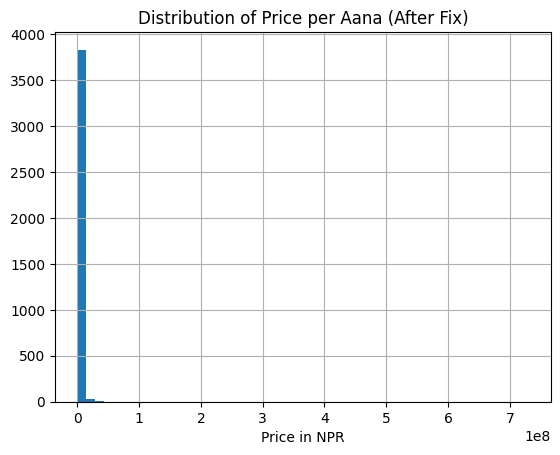

In [117]:
import matplotlib.pyplot as plt

# This should show a bell curve-like distribution between 1M and 10M
df1['price_per_aana'].hist(bins=50)
plt.title("Distribution of Price per Aana (After Fix)")
plt.xlabel("Price in NPR")
plt.show()

In [118]:
print("Top 10 highest prices (The outliers):")
print(df1['price_per_aana'].sort_values(ascending=False).head(10))

Top 10 highest prices (The outliers):
353     730000000.0
680     165000000.0
1949    123400000.0
3770    120000000.0
2365    111100000.0
3031    110000000.0
296      90000000.0
2342     50000000.0
47       45000000.0
583      31500000.0
Name: price_per_aana, dtype: float64


In [119]:
PRICE_CEILING = 20_000_000 

# Check how many rows are above this ceiling
outliers_count = len(temp_df1[temp_df1['price_per_aana'] > PRICE_CEILING])
print(f"Removing {outliers_count} rows that exceed the logical price ceiling of 2 Crore per aana.")
# Filter them out for the final master version
temp_df1 = temp_df1[temp_df1['price_per_aana'] <= PRICE_CEILING]

# Verify the new max
print(f"New Max Price: {temp_df1['price_per_aana'].max()}")

Removing 280 rows that exceed the logical price ceiling of 2 Crore per aana.
New Max Price: 20000000.0


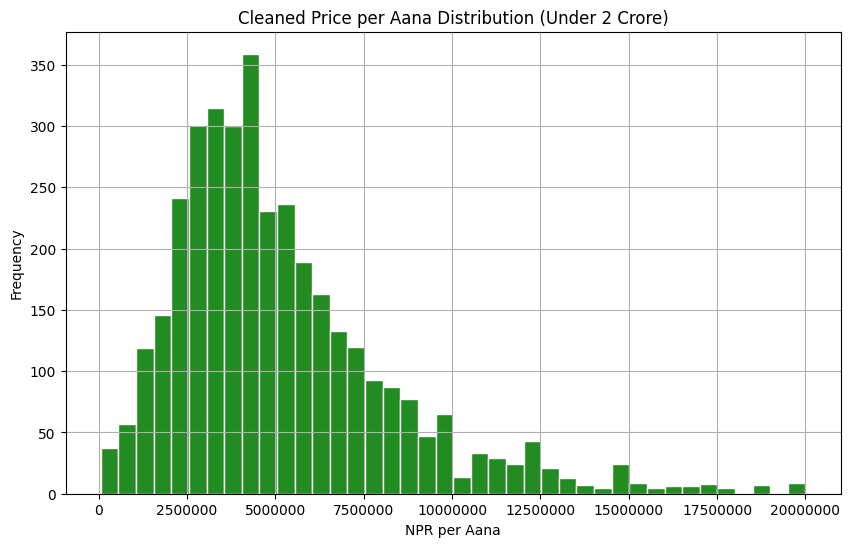

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
temp_df1['price_per_aana'].hist(bins=40, color='forestgreen', edgecolor='white')
plt.title("Cleaned Price per Aana Distribution (Under 2 Crore)")
plt.xlabel("NPR per Aana")
plt.ylabel("Frequency")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

In [121]:
df1=temp_df1.copy()

In [122]:
df1[df1['neighborhood']=='Unknown'].head()

,ad_id,title,location_raw,district,neighborhood,road_type,raw_price,land_size_aana,price_per_aana,calculated_total_price,is_price_suspect,is_price_outlier,is_rate_outlier,is_large_plot
79,HB-ED0C51,land for sale sanepa lalitpur 10 aana,"Lalitpur, Lalitpur Metropolitan City, Lalitpur",Lalitpur,Unknown,Above 20 Ft,8500000.0,10.0,8500000.0,85000000.0,False,False,False,False
102,HB-91AD1D,land for sale bhaisepati karevinayk lalitpur 1...,"Lalitpur, Lalitpur Metropolitan City, Lalitpur",Lalitpur,Unknown,Above 20 Ft,220000.0,17.0,220000.0,3740000.0,False,False,True,False
111,HB-515EA2,land for sale in basundhara,"Kathmandu-3, Kathmandu, Bagmati Pradesh",Kathmandu,Unknown,13-20 Ft,5500000.0,3.0,5500000.0,16500000.0,False,False,False,False
138,HB-C9BC97,sale,"Lalitpur-25, Lalitpur, Bagmati Pradesh",Lalitpur,Unknown,13-20 Ft,3700000.0,10.0,3700000.0,37000000.0,False,False,False,False
139,HB-C06F4E,sale,"Lalitpur-25, Lalitpur, Bagmati Pradesh",Lalitpur,Unknown,Above 20 Ft,5700000.0,7.0,5700000.0,39900000.0,False,False,False,False


In [123]:
df1.sample(2)

,ad_id,title,location_raw,district,neighborhood,road_type,raw_price,land_size_aana,price_per_aana,calculated_total_price,is_price_suspect,is_price_outlier,is_rate_outlier,is_large_plot
3572,HB-57930C,Sasto jagga bikrima @ Changunarayan,"Duwakot (Changunarayan), Bhaktapur",Bhaktapur,Duwakot,Gravel Road,3000000.0,3.3125,3000000.0,9937500.0,False,False,False,False
2728,HB-F14A25,Exclusive Land for Sale in Harisiddhi 4 aana 2...,"Harisiddhi, Lalitpur",Lalitpur,Harisiddhi,NaN,4500000.0,4.0000,4500000.0,18000000.0,False,False,False,False


In [124]:
def extract_neighborhood_from_raw(row):
    # Only run this if neighborhood is 'Unknown' or missing
    n = str(row['neighborhood']).strip().lower()
    
    if n in ['unknown', 'none', 'nan', '']:
        # 1. Get the raw location string
        raw = str(row['location_raw'])
        
        # 2. Extract the first part (before the first comma)
        # Example: "Bhangal, Budhanilkantha, Kathmandu" -> "Bhangal"
        extracted = raw.split(',')[0].strip()
        
        # 3. If extraction results in the same as district or is empty, 
        # use district as a last resort fallback
        if not extracted or extracted.lower() == str(row['district']).lower():
            return str(row['district']).title()
            
        return extracted.title()
    
    # If it wasn't 'Unknown', keep the original neighborhood
    return str(row['neighborhood']).title()

# Apply the function
temp_df1['neighborhood'] = temp_df1.apply(extract_neighborhood_from_raw, axis=1)

# Quick verification of those specific 86 rows
print("Examples of extracted neighborhoods from raw strings:")
print(df1[['location_raw', 'neighborhood', 'district']].head(10))

Examples of extracted neighborhoods from raw strings:
                                        location_raw           neighborhood  \
0                Tokha-3, Kathmandu, Bagmati Pradesh                  Tokha   
1           Kmc Hospital, Changunarayan-2, Bhaktapur          Changunarayan   
2  बूढानीलकण्ठ, बूढानीलकण्ठ नगरपालिका, काठमाडौं ज...            बूढानीलकण्ठ   
3  Godawari Bridge, Gwarko-Lamatar, Mahalaxmi-8, ...               Godawari   
4  बूढानीलकण्ठ, बूढानीलकण्ठ नगरपालिका, काठमाडौं ज...            बूढानीलकण्ठ   
5  F84, Tenzing Chok, Budhanilkantha, Budhanilkan...         Budhanilkantha   
6  Matatirtha, Chandragiri-6, Kathmandu, Bagmati ...             Matatirtha   
7  DAV Sushil Kedia Vishwa Bharati School, दमकल स...  दमकल सुन्दरीघाट मार्ग   
8  Swastik Marg, Kathmandu-14, Kathmandu, Bagmati...           Swastik Marg   
9  Damodar Marga, Ekantakuna, Lalitpur, Lalitpur ...             Ekantakuna   

    district  
0  Kathmandu  
1  Bhaktapur  
2  Kathmandu  
3   Lalitpur  
4

In [125]:
temp_df1[temp_df1['neighborhood']=='Unknown']

,ad_id,title,location_raw,district,neighborhood,road_type,raw_price,land_size_aana,price_per_aana,calculated_total_price,is_price_suspect,is_price_outlier,is_rate_outlier,is_large_plot


In [126]:
temp_df1[temp_df1['road_type'].isnull()]

,ad_id,title,location_raw,district,neighborhood,road_type,raw_price,land_size_aana,price_per_aana,calculated_total_price,is_price_suspect,is_price_outlier,is_rate_outlier,is_large_plot
1,HB-DC6CF2,Land for sale near kmc hospital,"Kmc Hospital, Changunarayan-2, Bhaktapur",Bhaktapur,Changunarayan,NaN,6500000.0,3.000000,6500000.0,1.950000e+07,False,False,False,False
3,HB-6CE9DF,Land on sale,"Godawari Bridge, Gwarko-Lamatar, Mahalaxmi-8, ...",Lalitpur,Godawari,NaN,3000000.0,3.500000,3000000.0,1.050000e+07,False,False,False,False
8,HB-6E7D12,6 aana perfect land on sale near Metro apartment,"Swastik Marg, Kathmandu-14, Kathmandu, Bagmati...",Kathmandu,Swastik Marg,NaN,9000000.0,6.000000,9000000.0,5.400000e+07,False,False,False,False
11,HB-589245,Land for Sale Kirtipur Near Jal Binayak Colony!,"Jalbinayak Colony, Kirtipur-6, Kathmandu",Kathmandu,Jalbinayak Colony,NaN,3200000.0,3.000000,3200000.0,9.600000e+06,False,False,False,False
15,HB-A58F36,Residential Land for Sale Old Naikap Near Kalanki,"Kalanki-14 Khadkagau, Chandragiri-13, Kathmandu",Kathmandu,Kalanki,NaN,2700000.0,3.500000,2700000.0,9.450000e+06,False,False,False,False
18,HB-93CC27,"RESIDENTIAL LAND ON SALE AT DHAPA VALLEY, Dhap...","Dhapa Valley, Lalitpur-24, Lalitpur",Lalitpur,Dhapa Valley,NaN,3250000.0,5.000000,3250000.0,1.625000e+07,False,False,False,False
26,HB-E9A7F8,5.5 Aana @ Sankhu- Near Malpot - @18 lacs/ Aana,"Sankhu Malpot Office, salinadi road, Shankhara...",Kathmandu,Shankharapur,NaN,1800000.0,5.500000,1800000.0,9.900000e+06,False,False,False,False
29,HB-867F84,Land on sale at machhegaun Naaikap 4Aana,"Chandragiri-9, Kathmandu, Bagmati Pradesh",Kathmandu,Chandragiri,NaN,2500000.0,5.843682,2500000.0,1.460920e+07,False,False,False,False
30,HB-A10874,land sale,620 Ward office - Ghamdhoka Marga Chagunarayan...,Bhaktapur,Chagunarayan Temmple,NaN,26.0,5.000000,2600000.0,1.300000e+07,False,False,False,False
38,HB-9EF6B4,Sasto jagga,"Lalitpur Nepal, Mahalaxmi-4, Lalitpur",Lalitpur,Mahalaxmi,NaN,650000.0,10.000000,650000.0,6.500000e+06,False,False,False,False


In [127]:
# Fill NaN values in road_type with "Unknown"
temp_df1['road_type'] = temp_df1['road_type'].fillna('Unknown')

# Standardize existing values (Title Case) so 'pitched' and 'Pitched' don't stay separate
temp_df1['road_type'] = temp_df1['road_type'].str.strip().str.title()

# Verify the count
print(f"Road Type - Unknown count: {len(df1[df1['road_type'] == 'Unknown'])}")
print("\nUnique Road Types now:")
print(temp_df1['road_type'].unique())

Road Type - Unknown count: 0

Unique Road Types now:
['Above 20 Ft' 'Unknown' '13-20 Ft' 'Gravel Road' 'Pitched Road' '9-12 Ft'
 'Full Road']


In [128]:
temp_df1['road_type'].isnull().sum()

np.int64(0)

In [129]:
df1=temp_df1.copy()

In [130]:
df3.columns

Index(['category', 'title', 'district', 'neighborhood', 'location_raw',
       'total_price', 'price_per_aana', 'land_area_aana', 'build_up_area',
       'floors', 'facing', 'road_width_feet', 'bedrooms', 'bathrooms',
       'parking_cars', 'parking_bikes', 'built_year_ad', 'house_age',
       'is_under_construction', 'amenity_count', 'has_modular_kitchen',
       'has_parquet', 'has_drainage', 'has_solar', 'has_parking', 'has_garden',
       'is_wide_road', 'is_commercial_suspect', 'is_area_estimated'],
      dtype='object')

In [131]:
import numpy as np

# 1. Identify your clean binary features (e.g., has_garden, has_parking, etc.)
# This finds every column you created during the split
premium_cols = [col for col in df3.columns if col.startswith('has_')]

# 2. Create a 'luxury_feature_score'
# Instead of trusting a raw count of 29 (which includes 'water' and 'electricity'),
# we count how many 'Premium' features we actually identified.
df3['luxury_score'] = df3[premium_cols].sum(axis=1)

# 3. Fix the 'amenity_count' Outliers
# We use .clip() to cap the count. In real estate data, a house with 15 
# amenities and a house with 29 are usually similar; the 29 just has more "filler".
# This prevents the 29 from being an "extreme outlier" in your model.
df3['amenity_count'] = df3['amenity_count'].clip(upper=15)

# 4. Handle any NaNs in the count (just in case)
df3['amenity_count'] = df3['amenity_count'].fillna(0).astype(int)

# 5. Verification
print("Amenity Stats After Fix:")
print(df3[['amenity_count', 'luxury_score']].describe())

# Check the top rows to see if luxury_score matches the vibe of the house
print("\nTop 5 High-Value Houses:")
print(df3.sort_values('luxury_score', ascending=False)[['title', 'amenity_count', 'luxury_score']].head())

Amenity Stats After Fix:
       amenity_count  luxury_score
count    2629.000000   2629.000000
mean        6.096995      2.217954
std         3.225202      0.944848
min         0.000000      0.000000
25%         4.000000      2.000000
50%         5.000000      2.000000
75%         8.000000      3.000000
max        15.000000      5.000000

Top 5 High-Value Houses:
                                                  title  amenity_count  \
52                                       House for Sale             11   
1040               House for sale at Nakkhu, Bhaisepati             10   
1020  Newly built house is on sale Italitar, Budhani...             10   
1046    Bungalow On Sale At Hattigaunda, Budhanilkantha             10   
1120  Luxurious Villas available at Downtown Housing...             11   

      luxury_score  
52               5  
1040             5  
1020             5  
1046             5  
1120             5  


In [132]:
df3.sample(12)

,category,title,district,neighborhood,location_raw,total_price,price_per_aana,land_area_aana,build_up_area,floors,facing,road_width_feet,bedrooms,bathrooms,parking_cars,parking_bikes,built_year_ad,house_age,is_under_construction,amenity_count,has_modular_kitchen,has_parquet,has_drainage,has_solar,has_parking,has_garden,is_wide_road,is_commercial_suspect,is_area_estimated,luxury_score
1901,house,"House on sale in Kapan, near Karuna Hospital",Kathmandu,Kapan,"Kapan, Kathmandu",11800000.0,3.933333e+06,3.0,718.72,1.0,West,15.0,NaN,NaN,0.0,0.0,2011.0,15.0,False,4,0,0,1,0,1,0,False,False,True,2
606,house,"Bungalow for sale in Shanta Colony, Hepali Height",Kathmandu,Hepali Height,"Hepali Height, Kathmandu",70000000.0,1.320755e+07,5.3,2539.49,2.0,East,17.0,4.0,4.0,0.0,0.0,2019.0,7.0,False,9,0,1,1,0,1,1,False,False,True,4
1824,house,Villa on sale in Chapali Budhanilkantha,Kathmandu,Chapali,"Chapali, Kathmandu",39000000.0,7.800000e+06,5.0,2994.69,2.5,North,18.0,6.0,8.0,0.0,0.0,2014.0,12.0,False,6,0,0,1,0,1,1,False,False,True,3
902,house,"Beautiful house for sale in Lalitpur, Bhaisepati",Lalitpur,Bhaisepati,"Bhaisepati, Lalitpur",35000000.0,1.060606e+07,3.3,1976.49,2.5,West,22.0,5.0,4.0,0.0,0.0,2014.0,12.0,False,5,0,0,1,0,1,0,False,False,True,2
1773,house,Brand new full furnished house on sale in Maha...,Kathmandu,Panitanki,"Panitanki, Kathmandu",37000000.0,9.250000e+06,4.0,3354.05,3.5,East,14.0,8.0,7.0,0.0,0.0,2011.0,15.0,False,6,0,0,1,0,1,0,False,False,True,2
2017,house,House on sale at Thankot,Kathmandu,Thankot,"Thankot, Kathmandu",16000000.0,3.809524e+06,4.2,2515.54,2.5,West,13.0,4.0,4.0,0.0,0.0,2013.0,13.0,False,5,0,0,1,0,1,0,False,False,True,2
893,house,"Beautiful house on sale at Imadol, Lalitpur",Lalitpur,Imadol,"Imadol, Lalitpur",65000000.0,5.416667e+06,12.0,8624.70,3.0,South,13.0,7.0,3.0,0.0,0.0,2019.0,7.0,False,5,0,0,1,0,1,0,False,False,True,2
1173,house,"Furnished bungalow for sale at Thado Dhunga, L...",Lalitpur,Thado Dhunga,"Thado Dhunga, Lalitpur",18000000.0,1.800000e+06,10.0,5989.38,2.5,North,15.0,3.0,3.0,0.0,0.0,2014.0,12.0,False,9,1,1,1,0,1,1,False,False,True,5
2021,house,"Brand new house on sale in Imadol, Lalitpur",Lalitpur,Gwarko,"Gwarko, Lalitpur",19500000.0,4.875000e+06,4.0,1200.00,2.0,North West,15.0,5.0,3.0,0.0,0.0,2020.0,6.0,False,10,1,1,1,0,1,0,False,False,False,4
1794,house,Beautiful bungalow on sale in Nakhipot,Lalitpur,Nakhipot,"Nakhipot, Lalitpur",60000000.0,7.317073e+06,8.2,1711.25,3.0,South East,15.0,6.0,6.0,0.0,0.0,2018.0,8.0,False,8,0,0,1,0,1,1,False,False,False,3


In [134]:
df1['category'] = 'land'

# Move 'category' to the first position for consistency with df3
cols = ['category'] + [col for col in df1.columns if col != 'category']
df1 = df1[cols]

In [135]:
# Create the category column
df2['category'] = 'land'

# Move 'category' to the first position
cols = ['category'] + [col for col in df2.columns if col != 'category']
df2 = df2[cols]

In [136]:
df1.columns

Index(['category', 'ad_id', 'title', 'location_raw', 'district',
       'neighborhood', 'road_type', 'raw_price', 'land_size_aana',
       'price_per_aana', 'calculated_total_price', 'is_price_suspect',
       'is_price_outlier', 'is_rate_outlier', 'is_large_plot'],
      dtype='object')

In [137]:
df2.columns

Index(['category', 'neighborhood', 'district', 'location_raw',
       'price_per_aana', 'land_size_aana', 'calculated_total_price',
       'road_width_feet', 'road_type', 'facing', 'is_wide_road',
       'is_price_suspect', 'is_large_plot', 'is_rate_outlier',
       'is_price_outlier'],
      dtype='object')

In [138]:
df3.columns

Index(['category', 'title', 'district', 'neighborhood', 'location_raw',
       'total_price', 'price_per_aana', 'land_area_aana', 'build_up_area',
       'floors', 'facing', 'road_width_feet', 'bedrooms', 'bathrooms',
       'parking_cars', 'parking_bikes', 'built_year_ad', 'house_age',
       'is_under_construction', 'amenity_count', 'has_modular_kitchen',
       'has_parquet', 'has_drainage', 'has_solar', 'has_parking', 'has_garden',
       'is_wide_road', 'is_commercial_suspect', 'is_area_estimated',
       'luxury_score'],
      dtype='object')

In [139]:
df1.to_csv('cleaned_hamrobazaar_land_v3.csv', index=False)
df2.to_csv('cleaned_nepali_land_v3.csv', index=False)
df3.to_csv('cleaned_nepali_houses_v3.csv', index=False)

In [140]:
import pandas as pd

print('=== df1 (HB Land) ===')
print('raw_price < 1000:', (df1['raw_price'] < 1000).sum())
print('raw_price < 10000:', (df1['raw_price'] < 10000).sum())
print('price_per_aana min/max:', df1['price_per_aana'].min(), '/', df1['price_per_aana'].max())
print('price_per_aana median:', df1['price_per_aana'].median())
print('neighborhood Unknown:', (df1['neighborhood'] == 'Unknown').sum())
print('neighborhood nulls:', df1['neighborhood'].isna().sum())
print('road_type nulls:', df1['road_type'].isna().sum())
print('road_type Unknown:', (df1['road_type'] == 'Unknown').sum())

print()


=== df1 (HB Land) ===
raw_price < 1000: 60
raw_price < 10000: 60
price_per_aana min/max: 60000.0 / 20000000.0
price_per_aana median: 4500000.0
neighborhood Unknown: 0
neighborhood nulls: 0
road_type nulls: 0
road_type Unknown: 748



In [141]:
import pandas as pd

print('=== df1 (HB Land) ===')
print('raw_price < 1000:', (temp_df1['raw_price'] < 1000).sum())
print('raw_price < 10000:', (temp_df1['raw_price'] < 10000).sum())
print('price_per_aana min/max:', temp_df1['price_per_aana'].min(), '/', df1['price_per_aana'].max())
print('price_per_aana median:', temp_df1['price_per_aana'].median())
print('neighborhood Unknown:', (temp_df1['neighborhood'] == 'Unknown').sum())
print('neighborhood nulls:', temp_df1['neighborhood'].isna().sum())
print('road_type nulls:', temp_df1['road_type'].isna().sum())
print('road_type Unknown:', (temp_df1['road_type'] == 'Unknown').sum())

=== df1 (HB Land) ===
raw_price < 1000: 60
raw_price < 10000: 60
price_per_aana min/max: 60000.0 / 20000000.0
price_per_aana median: 4500000.0
neighborhood Unknown: 0
neighborhood nulls: 0
road_type nulls: 0
road_type Unknown: 748


In [142]:
df1=temp_df1.copy()

In [143]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [144]:
temp_df1['neighborhood'].value_counts()

neighborhood
Budhanilkantha                                                                                                                       483
Nagarjun                                                                                                                             106
Bhaisepati                                                                                                                            99
Kirtipur                                                                                                                              92
Tokha                                                                                                                                 88
Chandragiri                                                                                                                           60
Baluwatar                                                                                                                             51
Sanepa                      

In [145]:
df1[df1['raw_price'] < 1000]


,ad_id,title,location_raw,district,neighborhood,road_type,raw_price,land_size_aana,price_per_aana,calculated_total_price,is_price_suspect,is_price_outlier,is_rate_outlier,is_large_plot
24,HB-177CBD,Land & House On Sell,"Khadka Bhadrakali, Budhanilkantha, Budhanilkan...",Kathmandu,Khadka Bhadrakali,Full Road,100.00,10.226443,10000000.0,1.022644e+08,False,False,False,False
30,HB-A10874,land sale,620 Ward office - Ghamdhoka Marga Chagunarayan...,Bhaktapur,Chagunarayan Temmple,Unknown,26.00,5.000000,2600000.0,1.300000e+07,False,False,False,False
46,HB-55D857,Medicity Hospital Najikai 1 Ropani 3 Paisa jagga,"Nakkhu Jal Binayak Marg, Lalitpur-18, Lalitpur...",Lalitpur,Nakkhu Jal Binayak Marg,Pitched Road,67.00,16.750000,6700000.0,1.122250e+08,False,False,False,False
92,HB-7FEE88,Kusume rumal justo mileko jagga,"Borcha, Mahalaxmi-8, Lalitpur, Bagmati Pradesh",Lalitpur,Borcha,Gravel Road,35.00,6.250000,3500000.0,2.187500e+07,False,False,False,False
112,HB-4FF159,Balambu ma mero 3.1 aana dachin mohoda singal ...,"F105, Chandragiri, Chandragiri Municipality, K...",Kathmandu,Chandragiri,13-20 Ft,32.00,3.000000,3200000.0,9.600000e+06,False,False,False,False
122,HB-9C58F6,"Land for Sale at Gajurel Danda, Mulpani","Gajurel Hill गजुरेल डाँडा, Kageshwori Manahora...",Kathmandu,Gajurel Hill गजुरेल डाँडा,Pitched Road,45.00,4.000000,4500000.0,1.800000e+07,False,False,False,False
162,HB-502D2B,Perfect land for sale 3.5 ana @Tathali bhaktapur,"Chundevi Tole Sadak, Changunarayan-9, Bhaktapu...",Bhaktapur,Chundevi Tole Sadak,Above 20 Ft,90.00,3.300000,9000000.0,2.970000e+07,False,False,False,False
171,HB-6F7895,13 Ana Land For Sell On Tinkune,"Tinkune Gairigaun, Kathmandu-14, Kathmandu",Kathmandu,Tinkune Gairigaun,Unknown,70.00,13.000000,7000000.0,9.100000e+07,False,False,False,False
189,HB-013613,"Dhapakhel, sunakoti, jharuwarashi land on sell","F1 soft Tower, Lalitpur-3, Lalitpur",Lalitpur,F1 Soft Tower,Pitched Road,25.35,8.000000,2535000.0,2.028000e+07,False,False,False,False
208,HB-6BFE83,Land on sale,"Balkot, Madhyapur Thimi-5, Bhaktapur",Bhaktapur,Balkot,Pitched Road,44.00,4.000000,4400000.0,1.760000e+07,False,False,False,False


In [147]:
df3.sample()

,category,title,district,neighborhood,location_raw,total_price,price_per_aana,land_area_aana,build_up_area,floors,facing,road_width_feet,bedrooms,bathrooms,parking_cars,parking_bikes,built_year_ad,house_age,is_under_construction,amenity_count,has_modular_kitchen,has_parquet,has_drainage,has_solar,has_parking,has_garden,is_wide_road,is_commercial_suspect,is_area_estimated,luxury_score
1522,house,"House on sale at Budhanilkantha, kathamandu",Kathmandu,Budhanilkantha,"Budhanilkantha, Kathmandu",36000000.0,7200000.0,5.0,2994.69,2.5,South West,14.0,6.0,5.0,0.0,0.0,1999.0,27.0,False,7,0,1,1,0,1,0,False,False,True,3
